# Forecasting Traffic Accidents Using Holt-Winters Time Series Models (ATUS 1997–2024)

This notebook analyzes traffic accident data from the ATUS (Accidentes de Tránsito) dataset, published by INEGI (Mexico’s National Institute of Statistics and Geography). The dataset contains monthly records of traffic accidents across Mexico from 1997 to 2024.

The objective of this analysis is to explore historical trends, identify seasonal patterns, and apply time series forecasting techniques to predict future accident behavior.

*   Libraries and Data

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

path_file = '/content/drive/MyDrive/Pandas cvs/Atus-2024.csv' # Path file
atus = pd.read_csv(path_file, encoding="utf-8-sig") # Reading and encoding type of the file

atus.head()

,Anio,Mes,Accidentes
0,1997,Enero,18515
1,1997,Febrero,18407
2,1997,Marzo,20004
3,1997,Abril,20175
4,1997,Mayo,20915


*   Exploratory Data Analysis (EDA)

This section explores the time series to identify trend, seasonality, and anomalies in order to justify the selected forecasting method.

In [ ]:
# Create month mapping
months = {
    "Enero":1,"Febrero":2,"Marzo":3,"Abril":4,"Mayo":5,"Junio":6,
    "Julio":7,"Agosto":8,"Septiembre":9,"Octubre":10,"Noviembre":11,"Diciembre":12
}

# Convert month to numeric
atus["Mes"] = atus["Mes"].str.strip()  # quitar espacios
atus["month"] = atus["Mes"].map(months)

# Create date column
atus["date"] = pd.to_datetime(dict(year=atus["Anio"], month=atus["month"], day=1))

# Sort values by date
atus = atus.sort_values("date")

# Create time series
ts = atus.set_index("date")["Accidentes"].astype(int)

print(atus)

     Anio         Mes  Accidentes  month       date
0    1997       Enero       18515      1 1997-01-01
1    1997     Febrero       18407      2 1997-02-01
2    1997       Marzo       20004      3 1997-03-01
3    1997       Abril       20175      4 1997-04-01
4    1997        Mayo       20915      5 1997-05-01
..    ...         ...         ...    ...        ...
331  2024      Agosto       30465      8 2024-08-01
332  2024  Septiembre       30037      9 2024-09-01
333  2024     Octubre       32456     10 2024-10-01
334  2024   Noviembre       32742     11 2024-11-01
335  2024   Diciembre       32177     12 2024-12-01

[336 rows x 5 columns]


In [ ]:
print(ts.head())
print(ts.dtypes)
print(ts.isna().sum())

date
1997-01-01    18515
1997-02-01    18407
1997-03-01    20004
1997-04-01    20175
1997-05-01    20915
Name: Accidentes, dtype: int64
int64
0


*   Plotting data

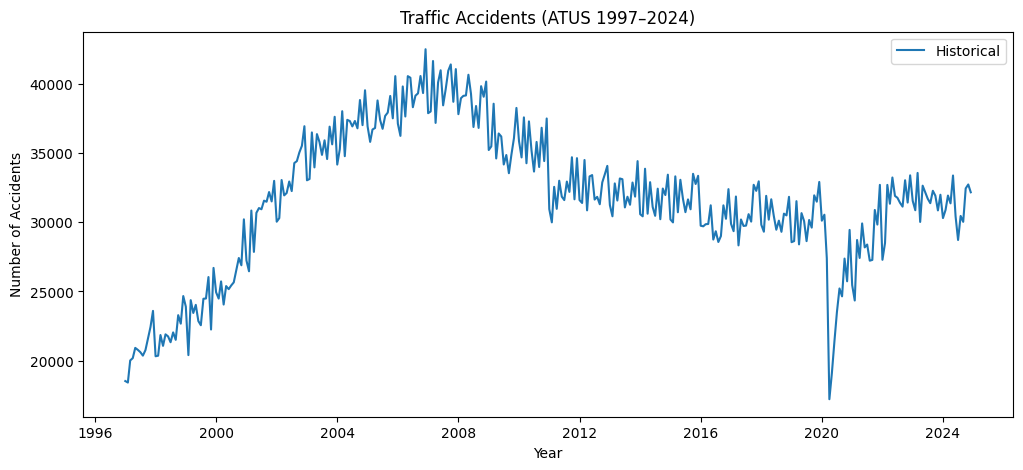

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(ts, label="Historical")
plt.legend()
plt.title("Traffic Accidents (ATUS 1997–2024)")
plt.xlabel("Year")
plt.ylabel("Number of Accidents")
plt.show()

After visualizing the time series, the Holt-Winters additive method was selected as the most appropriate forecasting approach.
The plot reveals a clear seasonal pattern with relatively constant fluctuations over time, as well as a moderate trend component.

The relatively constant seasonal fluctuations support the use of an additive approach for accurate forecasting.

In [ ]:
atus[atus["Anio"] == 2020].head(12) # Filter the dataset to display records for the year 2020

,Anio,Mes,Accidentes,month,date
276,2020,Enero,30121,1,2020-01-01
277,2020,Febrero,30554,2,2020-02-01
278,2020,Marzo,27403,3,2020-03-01
279,2020,Abril,17200,4,2020-04-01
280,2020,Mayo,19074,5,2020-05-01
281,2020,Junio,21392,6,2020-06-01
282,2020,Julio,23505,7,2020-07-01
283,2020,Agosto,25217,8,2020-08-01
284,2020,Septiembre,24644,9,2020-09-01
285,2020,Octubre,27379,10,2020-10-01


The April 2020 outlier was replaced using the average of April 2019 and April 2021 to maintain seasonal consistency.

In [ ]:
# Replace the anomalous value with the average of April 2019 and April 2021
april_2019 = atus[(atus["Anio"] == 2019) & (atus["Mes"] == "Abril")]["Accidentes"].values[0]
april_2021 = atus[(atus["Anio"] == 2021) & (atus["Mes"] == "Abril")]["Accidentes"].values[0]

new = (april_2019 + april_2021) / 2

print(new)

# Update the outlier value
atus.loc[
    (atus["Anio"] == 2020) & (atus["Mes"] == "Abril"),
    "Accidentes"
] = new

27916.0


Display 2020 data to verify the updated value after outlier correction.

In [ ]:
atus[atus["Anio"] == 2020].head(12)

,Anio,Mes,Accidentes,month,date
276,2020,Enero,30121,1,2020-01-01
277,2020,Febrero,30554,2,2020-02-01
278,2020,Marzo,27403,3,2020-03-01
279,2020,Abril,27916,4,2020-04-01
280,2020,Mayo,19074,5,2020-05-01
281,2020,Junio,21392,6,2020-06-01
282,2020,Julio,23505,7,2020-07-01
283,2020,Agosto,25217,8,2020-08-01
284,2020,Septiembre,24644,9,2020-09-01
285,2020,Octubre,27379,10,2020-10-01


*   Modeling

A Holt-Winters additive model is fitted to the time series, capturing both trend and seasonal components. The model is configured for monthly data with a seasonal period of 12, and parameters are automatically optimized during training.

In [ ]:
# Fit Holt-Winters additive model with trend and seasonality (monthly data)
model = ExponentialSmoothing(
    ts,
    trend='add',
    seasonal='add',
    seasonal_periods=12
)

# Train the model and estimate optimal parameters
model_fit = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


*   Forecast

Forecasts monthly values for 2025 and computes the total annual prediction.

In [ ]:
# Generate forecast for the next 12 months (2025)
forecast_2025 = model_fit.forecast(12)

# Calculate total predicted accidents for 2025
total_2025 = forecast_2025.sum()

# Display monthly forecast and total
print(forecast_2025)
print("Estimated total for 2025:", total_2025)

2025-01-01    29550.781674
2025-02-01    29395.003933
2025-03-01    31674.364106
2025-04-01    29276.971413
2025-05-01    31459.693699
2025-06-01    30604.667840
2025-07-01    30036.861112
2025-08-01    30694.050523
2025-09-01    30402.952703
2025-10-01    32257.018826
2025-11-01    31143.129137
2025-12-01    32936.817042
Freq: MS, dtype: float64
Estimated total for 2025: 369432.31200999825


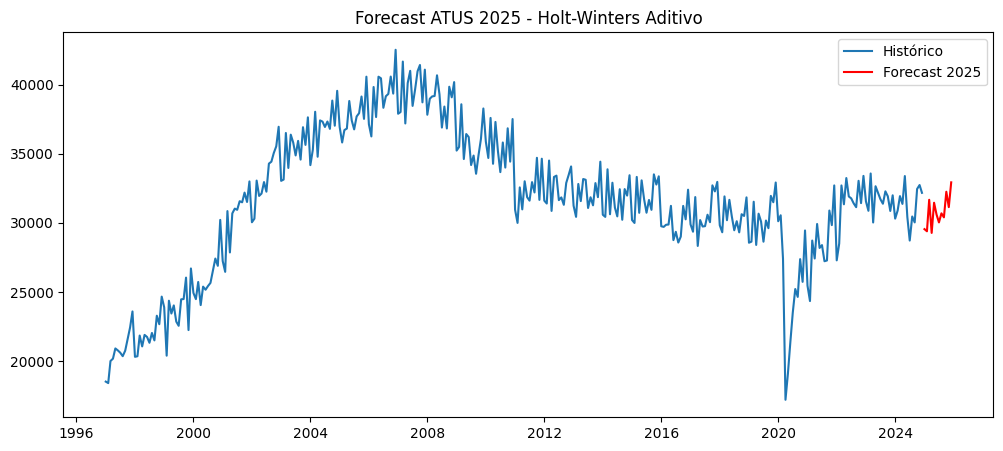

In [ ]:
# 2025 Forecast Visualization
plt.figure(figsize=(12,5))
plt.plot(ts, label="Histórico")
plt.plot(forecast_2025, label="Forecast 2025", color="red")
plt.legend()
plt.title("Forecast ATUS 2025 - Holt-Winters Aditivo")
plt.show()

*   Model Evaluation and Insights

In [ ]:
# Displays the optimized smoothing parameters and initial components of the model
model_fit.params

{'smoothing_level': np.float64(0.765220998387314),
 'smoothing_trend': np.float64(0.0),
 'smoothing_seasonal': np.float64(0.06514478811061568),
 'damping_trend': nan,
 'initial_level': np.float64(20718.21903668307),
 'initial_trend': np.float64(22.50543814779706),
 'initial_seasons': array([ -238.78112027, -1613.34010266,   924.93721712,  -893.47919101,
          310.58194141,  -186.37827966,  -673.12756442,  -189.69863897,
         -195.92036562,   880.59498277,  -320.69319384,  2192.06894208]),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

In [ ]:
# Define actual and predicted values
y_real = ts
y_pred = model_fit.fittedvalues

# Verify that both series are aligned
y_real.index.equals(y_pred.index)

# Calculate evaluation metrics
# DAM (MAE)
mae = np.mean(np.abs(y_real - y_pred))

# ECM (MSE)
mse = np.mean((y_real - y_pred)**2)

# PEMA (MAPE)
mape = np.mean(np.abs((y_real - y_pred) / y_real)) * 100

print("MAE:", mae)
print("MSE:", mse)
print("MAPE:", mape)

MAE: 836.5675017924607
MSE: 1383451.3429285458
MAPE: 2.8236975619027724


*   Results

The Holt-Winters additive model shows strong performance, with a low forecasting error (MAPE ≈ 2.8%), indicating high accuracy in capturing the time series behavior. The relatively small MAE confirms that prediction errors are minor compared to the scale of the data, while the MSE suggests limited impact from larger deviations.

Model parameters reveal that the level component is highly responsive to recent observations (high α), while the trend component is minimal (β ≈ 0), indicating no strong long-term trend. The low seasonal smoothing parameter (γ) reflects stable and consistent seasonal patterns over time.

Overall, the model effectively captures the underlying structure of the data and provides reliable forecasts.

*   Data source

Road traffic accidents.

Search for: Traffic Accidents By: Month of occurrence According to: Year of occurrence

Source: INEGI. Statistics on road traffic accidents in urban and suburban areas.

URL:  https://www.inegi.org.mx/sistemas/olap/proyectos/bd/continuas/transporte/accidentes.asp?s=est&c=13159&proy=atus_accidentes

Public dataset: https://drive.google.com/file/d/1kDaeJ8YWsDm1B5zPJQ9RjhkafH68mKnd/view?usp=sharing